## What is Random Forest?

**Random Forest** is an ensemble machine learning algorithm that builds multiple decision trees and combines their predictions to produce a more accurate and stable model.It belongs to the **ensemble learning** family and is based on the concept of **bagging (Bootstrap Aggregation)**.

The implementation used in this notebook comes from scikit-learn.


### Type of Machine Learning Problem

This notebook demonstrates **supervised classification**.

The model predicts **categorical labels** based on input features.


### Real-World Applications

Random Forest is widely used in:

* Fraud detection
* Medical diagnosis
* Credit risk prediction
* Customer churn prediction
* Recommendation systems
* Bioinformatics


### Why Random Forest is Useful

Advantages include:


* High accuracy
* Handles nonlinear relationships
* Works well with large datasets
* Resistant to overfitting compared to single trees
* Handles both categorical and numerical features

**Importing Libraries**

In [1]:
# Data handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# Model
from sklearn.ensemble import RandomForestClassifier

# Hyperparameter tuning
from sklearn.model_selection import GridSearchCV

# Evaluation metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    precision_recall_curve
)

# Model explainability
import shap

# Model saving
import joblib

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

**Load dataset**

We will use the Breast Cancer Dataset from sklearn.

This dataset predicts whether a tumor is **malignant** or **benign** .

In [2]:
data = load_breast_cancer()

In [3]:
X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target, name="target")

In [4]:
print("Shape of dataset:", X.shape)

Shape of dataset: (569, 30)


In [5]:
X.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [6]:
print(data.target_names)

['malignant' 'benign']


**Exploratory Data Analysis (EDA)**

In [7]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 30 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         5

In [8]:
# Check missing values
X.isnull().sum()

mean radius                0
mean texture               0
mean perimeter             0
mean area                  0
mean smoothness            0
mean compactness           0
mean concavity             0
mean concave points        0
mean symmetry              0
mean fractal dimension     0
radius error               0
texture error              0
perimeter error            0
area error                 0
smoothness error           0
compactness error          0
concavity error            0
concave points error       0
symmetry error             0
fractal dimension error    0
worst radius               0
worst texture              0
worst perimeter            0
worst area                 0
worst smoothness           0
worst compactness          0
worst concavity            0
worst concave points       0
worst symmetry             0
worst fractal dimension    0
dtype: int64

In [9]:
# Statistical summary
print("\nStatistical summary:\n", X.describe())


Statistical summary:
        mean radius  mean texture  mean perimeter    mean area  \
count   569.000000    569.000000      569.000000   569.000000   
mean     14.127292     19.289649       91.969033   654.889104   
std       3.524049      4.301036       24.298981   351.914129   
min       6.981000      9.710000       43.790000   143.500000   
25%      11.700000     16.170000       75.170000   420.300000   
50%      13.370000     18.840000       86.240000   551.100000   
75%      15.780000     21.800000      104.100000   782.700000   
max      28.110000     39.280000      188.500000  2501.000000   

       mean smoothness  mean compactness  mean concavity  mean concave points  \
count       569.000000        569.000000      569.000000           569.000000   
mean          0.096360          0.104341        0.088799             0.048919   
std           0.014064          0.052813        0.079720             0.038803   
min           0.052630          0.019380        0.000000           

**Target Distribution**

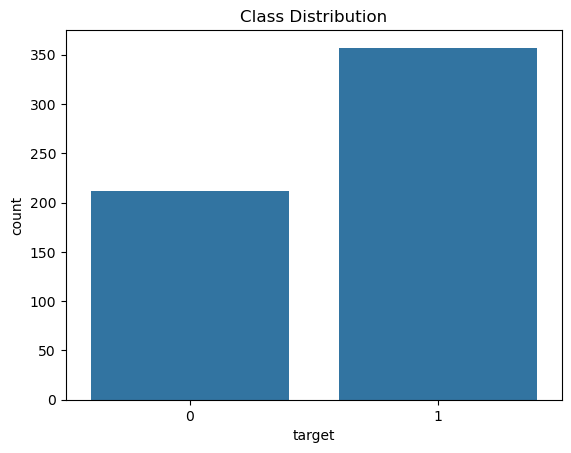

In [10]:
sns.countplot(x=y)
plt.title("Class Distribution")
plt.show()

**Feature Correlation Matrix**

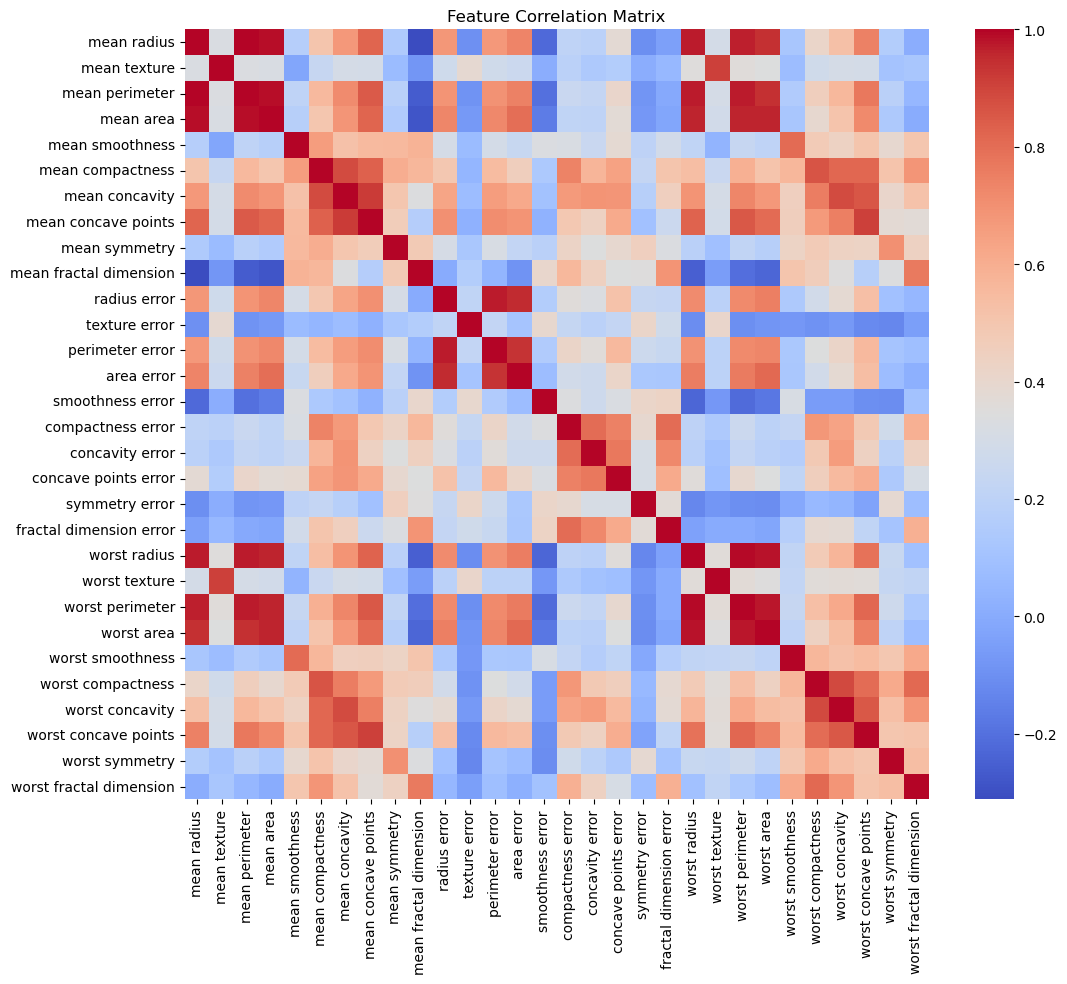

In [11]:
plt.figure(figsize=(12,10))
sns.heatmap(X.corr(), cmap="coolwarm")
plt.title("Feature Correlation Matrix")
plt.show()

**Feature Distribution**

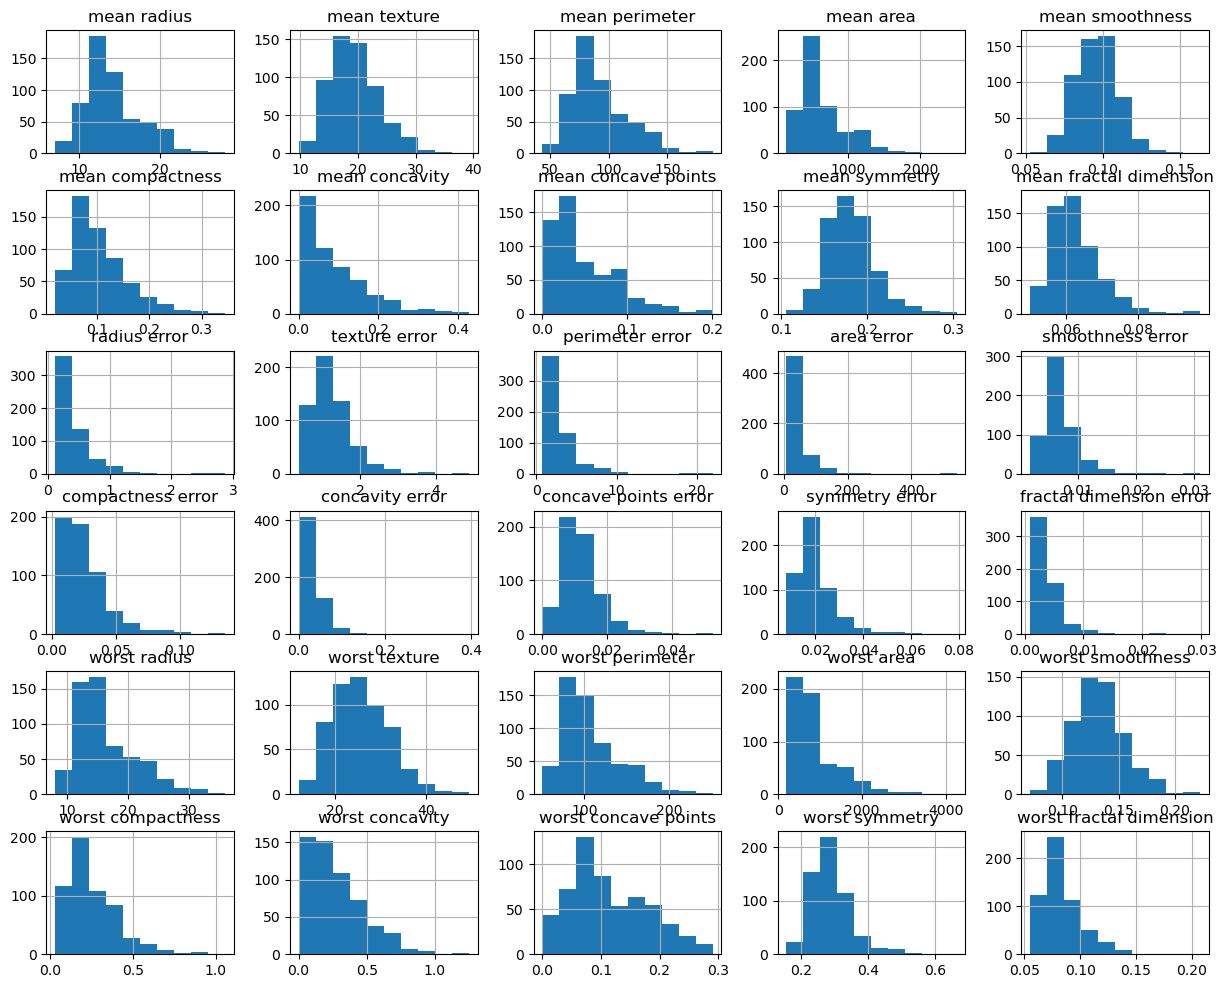

In [12]:
X.hist(figsize=(15,12))
plt.show()

**Data Preprocessing**

Random Forest does not require feature scaling, but we include it for pipeline consistency.

In [13]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

**Feature Engineering**

In [14]:
from sklearn.feature_selection import SelectKBest, f_classif

selector = SelectKBest(score_func=f_classif, k=10)

X_selected = selector.fit_transform(X, y)

selected_features = X.columns[selector.get_support()]

print(selected_features)

Index(['mean radius', 'mean perimeter', 'mean area', 'mean concavity',
       'mean concave points', 'worst radius', 'worst perimeter', 'worst area',
       'worst concavity', 'worst concave points'],
      dtype='object')


**Train-Test Split**

In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X_selected,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [16]:
print(f"Train shape: {X_train.shape}, Test shape: {X_test.shape}")

Train shape: (455, 10), Test shape: (114, 10)


**Machine Learning Pipeline**

In [17]:
pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", RandomForestClassifier(random_state=42))
])

In [18]:
pipeline.fit(X_train, y_train)

Pipeline(steps=[('scaler', StandardScaler()),
                ('model', RandomForestClassifier(random_state=42))])

**Hyperparameter Tuning**

In [19]:
param_grid = {
    "model__n_estimators": [100, 200],
    "model__max_depth": [5, 10, None],
    "model__min_samples_split": [2, 5],
    "model__min_samples_leaf": [1, 2]
}

In [20]:
grid = GridSearchCV(
    pipeline,
    param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

grid.fit(X_train, y_train)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('scaler', StandardScaler()),
                                       ('model',
                                        RandomForestClassifier(random_state=42))]),
             n_jobs=-1,
             param_grid={'model__max_depth': [5, 10, None],
                         'model__min_samples_leaf': [1, 2],
                         'model__min_samples_split': [2, 5],
                         'model__n_estimators': [100, 200]},
             scoring='accuracy')

**Best Parameters**

In [21]:
print("Best Parameters:", grid.best_params_)
print("Best CV Score:", grid.best_score_)

Best Parameters: {'model__max_depth': 5, 'model__min_samples_leaf': 2, 'model__min_samples_split': 5, 'model__n_estimators': 100}
Best CV Score: 0.9472527472527472


**Model Evaluation**

In [22]:
best_model = grid.best_estimator_

y_pred = best_model.predict(X_test)
y_prob = best_model.predict_proba(X_test)[:,1]

In [23]:
# Classification metrics
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print("ROC AUC:", roc_auc_score(y_test, y_prob))

Accuracy: 0.9649122807017544
Precision: 0.9722222222222222
Recall: 0.9722222222222222
F1 Score: 0.9722222222222222
ROC AUC: 0.9927248677248677


In [24]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.95      0.95      0.95        42
           1       0.97      0.97      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.96      0.96       114
weighted avg       0.96      0.96      0.96       114



**Visualization of Results**

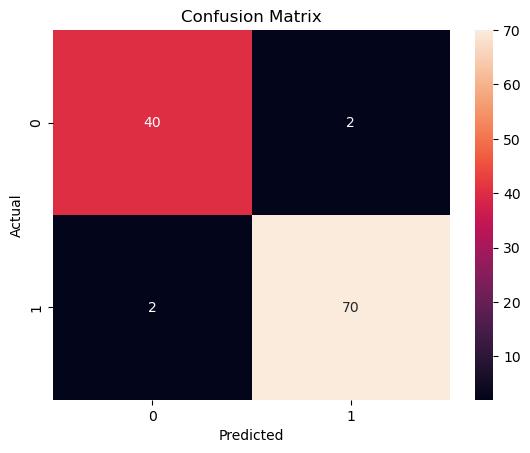

In [25]:
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt="d")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

**ROC Curve**

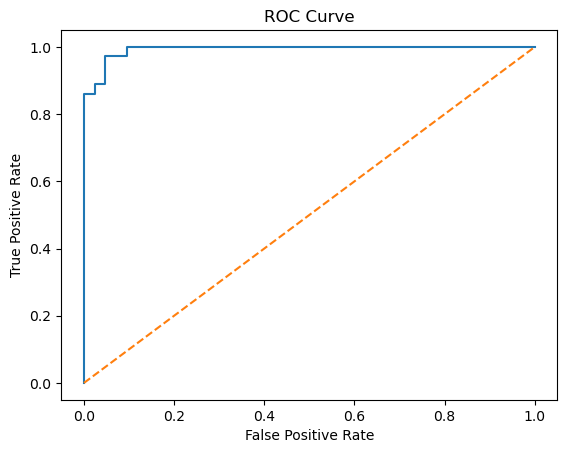

In [26]:
fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.plot(fpr, tpr)
plt.plot([0,1],[0,1],'--')
plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.show()

**Precision-Recall Curve**

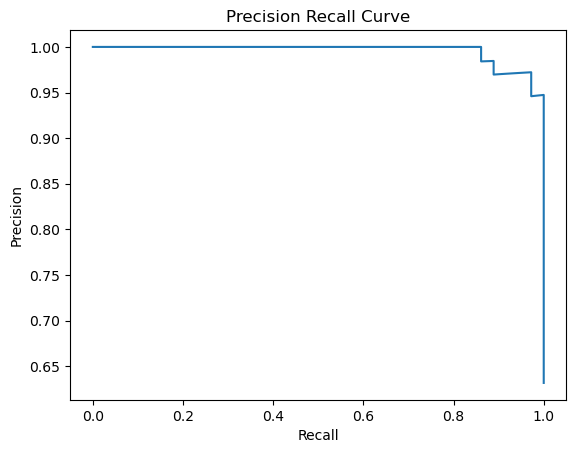

In [27]:
precision, recall, _ = precision_recall_curve(y_test, y_prob)

plt.plot(recall, precision)
plt.title("Precision Recall Curve")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.show()

**Feature Importance**

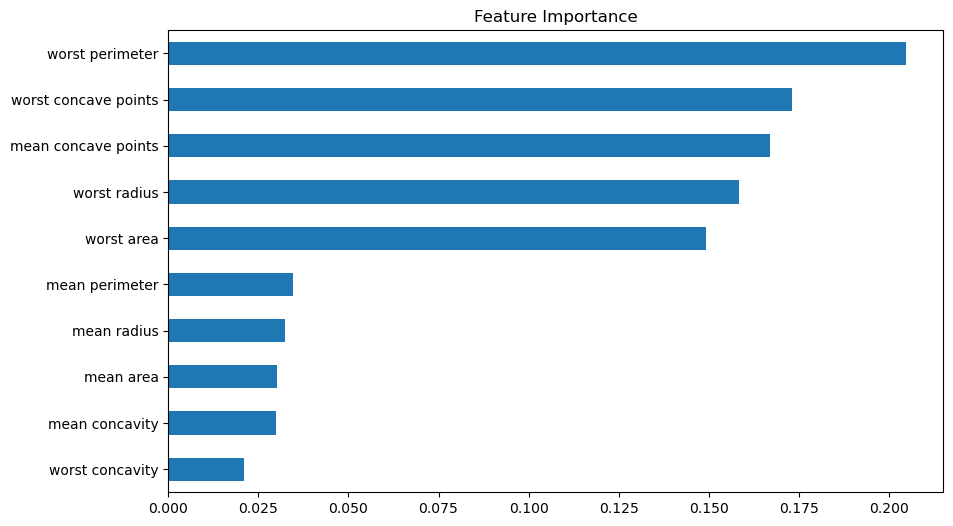

In [28]:
model = best_model.named_steps["model"]

importance = model.feature_importances_

feat_imp = pd.Series(importance, index=selected_features)

feat_imp.sort_values().plot(kind="barh", figsize=(10,6))

plt.title("Feature Importance")
plt.show()

**Model Explainability**

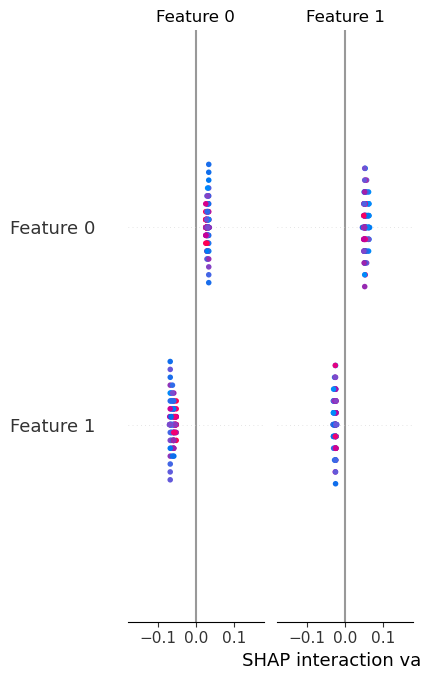

In [29]:
explainer = shap.TreeExplainer(model)

shap_values = explainer.shap_values(X_test)

shap.summary_plot(shap_values, X_test)

**Final Model Insights**

### Key Observations

* Random Forest performs well on tabular datasets.
* Ensemble learning improves prediction stability.
* Feature importance highlights influential predictors.
* Cross-validation ensures model generalization.

### Overfitting Check

Compare:

* Training accuracy
* Validation accuracy

If training accuracy >> test accuracy → overfitting.

**Saving the Model**

In [30]:
joblib.dump(best_model, "random_forest_model.pkl")

print("Model saved successfully!")

Model saved successfully!


##  Model Theory — Random Forest


### 1. Algorithm Overview

Random Forest works by:

1. Creating multiple decision trees.
2. Training each tree on a **bootstrap sample**.
3. Selecting random feature subsets for splits.
4. Aggregating predictions using **majority voting**.


### 2. Mathematical Intuition

Random Forest reduces variance by averaging predictions:

$$
Prediction = \frac{1}{N}\sum_{i=1}^{N} Tree_i(x)
$$

Where:

* $(N)$ = number of trees
* $(Tree_i)$ = prediction from each tree



### 3. When to Use Random Forest

Best for:

* Tabular datasets
* Medium-size datasets
* Nonlinear relationships
* Feature importance analysis



### 4. Advantages

- High accuracy
- Handles missing data
- Robust to outliers
- Works with high-dimensional data
- Provides feature importance



### 5. Disadvantages

- Can be slow with many trees
- Less interpretable than single trees
- Large memory usage
- Not ideal for real-time systems

